# Stage 10 — Final Mars model-input generation

_Pipeline stage 10 of `docs/PIPELINE_DESIGN.md`. Uses the canonical `channel_heads` package + on-disk artifacts; heavy rebuilds run via the `channel-heads` CLI (see each stage's command)._

## Mars model inputs — same patches, frozen CNN

Mars geometry (topology->pairs->features) is shared across regimes and raster-
independent. The raster-dependent part — **5-class patches** — is regenerated with the
*current* rasterizer (matching the Earth patches the CNN trained on), then embedded
with the **frozen** `cnn_outlet_final.pt`. Patches **must stay 5-class**. Build:
`python -m channel_heads run-mars-pipeline --stage patches` / `--stage embeddings`.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
REGIMES_ = ['regA', 'regB', 'regC']
# Frozen model features (5 dimensionless) + operating thresholds (Stage 9).
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
OP_THR = {'regA': 0.756326, 'regB': 0.779264, 'regC': 0.759369}
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


In [2]:
idx = MARS_IN / 'mars_cnn_patch_index.parquet'
if idx.exists():
    d = pd.read_parquet(idx)
    print('Mars patches:', len(d), '|',
          d['patch_status'].value_counts().to_dict() if 'patch_status' in d else '')

Mars patches: 3785 | {'ok': 3682, 'invalid': 103}


### Example Mars 5-class patches

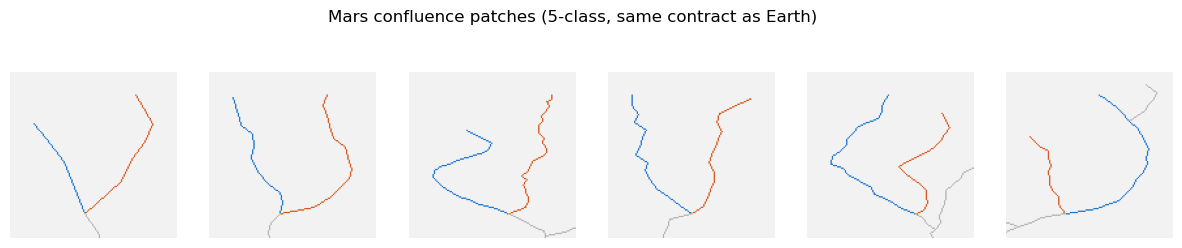

In [3]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap([[0.95,0.95,0.95],[0.85,0.33,0.10],[0.10,0.45,0.82],
                       [0.70,0.70,0.70],[0.90,0.80,0.0]])
d = pd.read_parquet(MARS_IN / 'mars_cnn_patch_index.parquet')
col = 'patch_path' if 'patch_path' in d else 'raster_path'
ok = d[d.get('patch_status','ok') == 'ok'].head(6)
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for ax, (_, row) in zip(axes, ok.iterrows()):
    pp = Path(row[col]); pp = pp if pp.is_absolute() else ROOT / pp
    a = np.load(pp); lab = a.argmax(0) if a.ndim == 3 else a
    ax.imshow(lab, cmap=cmap, vmin=0, vmax=4); ax.axis('off')
plt.suptitle('Mars confluence patches (5-class, same contract as Earth)'); plt.show()

Deep dives: `notebooks/mars/{02_first_meet_pairs,03_pair_features}.ipynb`.